
# Phishing Website Detection — Training & Evaluation Notebook

Pipeline ini sepenuhnya mengacu pada `app.py` dan `train_model.py`:
- Feature extraction sesuai `extract_url_features()` di `app.py`
- Rule-based prefilter sesuai `rule_based_eval()` di `app.py`
- GA tuning, training, dan stacking sesuai `train_model.py`
- Decision logic: threshold `0.6`, mode `hybrid_prefilter` sesuai `FINAL_THRESHOLD` dan `DEFAULT_DECISION_MODE` di `app.py`
- Semua metrik dievaluasi: Accuracy, Precision, Recall, F1, AUC, TP/TN/FP/FN, Batch Throughput, Latency

## 1. Import Library & Konfigurasi

In [12]:
import os
import json
import math
import pickle
import random
import time
import ipaddress
import re
import warnings
import pathlib
from urllib.parse import urlparse, urljoin

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import tldextract
from IPython.display import display

from deap import base, creator, tools, algorithms
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ── Konstanta sesuai app.py & train_model.py ─────────────────────────────────
RANDOM_STATE    = 12
TEST_SIZE       = 0.2
TARGET_COL      = "label"
FINAL_THRESHOLD = 0.6          # sesuai FINAL_THRESHOLD di app.py
PREFILTER_PHISHING_MIN_CONF = 0.95  # sesuai app.py

# GA settings (sesuai train_model.py)
GA_POP_SIZE  = 16
GA_N_GEN     = 8
GA_CXPB      = 0.7
GA_MUTPB     = 0.3
GA_CV_SPLITS = 5               # train_model.py pakai 5

# Konstanta feature-set sesuai app.py
SHORTENERS = {"bit.ly","goo.gl","tinyurl.com","ow.ly","t.co","is.gd","buff.ly","adf.ly","bit.do","cutt.ly"}
SUSPICIOUS_TLD = ["zip","xyz","top","tk","ga","ml","gq","cf","pw","cc","club","ws","biz",
                  "online","site","live","work","icu","info","cn","ru","loan","download","click"]
STANDARD_PORTS = {21,22,23,80,443,445,1433,1521,3306,3389}
PHISH_HINTS = ["login","verify","update","secure","account","bank","paypal","apple",
               "microsoft","confirm","signin","password"]
BRANDS = ["google","facebook","apple","microsoft","amazon","paypal","instagram",
          "whatsapp","telegram","netflix","github","linkedin"]

# 37 URL features (train_model.py: url_features_37)
url_features_37 = [
    "length_url","length_hostname","ip","nb_dots","nb_hyphens","nb_at","nb_qm","nb_and",
    "nb_eq","nb_underscore","nb_tilde","nb_percent","nb_slash","nb_star","nb_colon",
    "nb_comma","nb_semicolumn","nb_dollar","nb_space","nb_www","nb_com","nb_dslash",
    "http_in_path","https_token","ratio_digits_url","ratio_digits_host","punycode","port",
    "tld_in_path","tld_in_subdomain","abnormal_subdomain","nb_subdomains","prefix_suffix",
    "random_domain","shortening_service","path_extension","nb_redirection",
]

# Path dataset
notebook_dir  = pathlib.Path().resolve()
data_file_path = str(notebook_dir / "DataFiles" / "data_cleaning.csv")

_TLD_EXTRACTOR = tldextract.TLDExtract(suffix_list_urls=None)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)

def clamp(v, lo, hi):
    return max(lo, min(hi, v))

seed_everything(RANDOM_STATE)
print("✅ Konfigurasi selesai.")
print(f"   FINAL_THRESHOLD : {FINAL_THRESHOLD}")
print(f"   GA_CV_SPLITS    : {GA_CV_SPLITS}")
print(f"   url_features_37 : {len(url_features_37)} fitur")

✅ Konfigurasi selesai.
   FINAL_THRESHOLD : 0.6
   GA_CV_SPLITS    : 5
   url_features_37 : 37 fitur


## 2. Load & Audit Dataset

In [13]:
if not os.path.exists(data_file_path):
    raise FileNotFoundError(f"Dataset tidak ditemukan: {data_file_path}")

df = pd.read_csv(data_file_path)
df.columns = df.columns.str.strip()

dup_cols       = df.columns[df.columns.duplicated()].tolist()
whitespace_cols = [c for c in df.columns if c != c.strip()]
missing_target  = df[TARGET_COL].isna().sum() if TARGET_COL in df.columns else "N/A"

display(pd.DataFrame({
    "Metrik": ["Total Baris", "Total Kolom", "Kolom Duplikat",
               "Kolom Spasi Tersembunyi", "Label Hilang"],
    "Nilai" : [df.shape[0], df.shape[1],
               len(dup_cols) or "✅ Tidak ada",
               len(whitespace_cols) or "✅ Tidak ada",
               missing_target]
}))

print("\n👀 Sampel 3 baris teratas:")
display(df.head(3))

print("\n📊 Distribusi label:")
display(df[TARGET_COL].value_counts().rename({0:"Benign (0)", 1:"Phishing (1)"}).to_frame("Jumlah"))

,Metrik,Nilai
0,Total Baris,11429
1,Total Kolom,83
2,Kolom Duplikat,✅ Tidak ada
3,Kolom Spasi Tersembunyi,✅ Tidak ada
4,Label Hilang,0



👀 Sampel 3 baris teratas:


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,label
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,0
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,1
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,3,...,1,0,0,14,4004,5828815,0,1,0,1



📊 Distribusi label:


,Jumlah
label,
Benign (0),5715
Phishing (1),5714


## 3. Feature Extraction Functions

In [14]:
def entropy(s):
    if not s: return 0.0
    return -sum((s.count(c)/len(s))*math.log2(s.count(c)/len(s)) for c in set(s))

def is_ip(hostname):
    try: ipaddress.ip_address(hostname); return 1
    except: return 0

def parse_url(url):
    u = (url or "").strip()
    if not u.startswith(("http://","https://")): u = "http://" + u
    parsed = urlparse(u)
    return u, parsed, (parsed.hostname or "").lower(), parsed.path or ""

def _extract_parts(hostname):
    e = _TLD_EXTRACTOR(hostname or "")
    return (e.subdomain or "").lower(), (e.domain or "").lower(), (e.suffix or "").lower()

def _word_stats(text):
    words = re.findall(r"[A-Za-z0-9]+", (text or "").lower())
    if not words: return 0, 0, 0, 0.0
    lens = [len(w) for w in words]
    return len(words), min(lens), max(lens), float(sum(lens))/len(lens)

# Fungsi ini 1:1 dengan extract_url_features() di app.py
def extract_url_features(url):
    full, parsed, hostname, path = parse_url(url)
    subdomain, domain, tld = _extract_parts(hostname)
    digits_url  = sum(c.isdigit() for c in full)
    digits_host = sum(c.isdigit() for c in hostname)
    words_raw, shortest_raw, longest_raw, avg_raw     = _word_stats(full)
    _, shortest_host, longest_host, avg_host           = _word_stats(hostname)
    _, shortest_path, longest_path, avg_path           = _word_stats(path)
    random_domain       = 1 if entropy(domain) > 3.5 else 0
    shortening_service  = 1 if any(s in hostname for s in SHORTENERS) else 0
    prefix_suffix       = 1 if "-" in domain else 0
    path_extension      = 1 if "." in path.split("/")[-1] else 0
    nb_redirection      = max(full.lower().count("http") - 1, 0)
    try: parsed_port = parsed.port
    except ValueError: parsed_port = None
    port_flag           = 1 if (parsed_port is not None and parsed_port not in STANDARD_PORTS) else 0
    tld_last            = tld.split(".")[-1] if tld else ""
    suspicious_tld_flag = 1 if (tld in SUSPICIOUS_TLD or tld_last in SUSPICIOUS_TLD) else 0
    domain_in_brand     = 1 if any(b in domain for b in BRANDS) else 0
    brand_in_subdomain  = 1 if any(b in subdomain for b in BRANDS) else 0
    brand_in_path       = 1 if any(b in path.lower() for b in BRANDS) else 0
    statistical_report  = 1 if (suspicious_tld_flag or is_ip(hostname) or full.count("@")>=1 or random_domain) else 0

    return {
        "length_url": len(full), "length_hostname": len(hostname), "ip": is_ip(hostname),
        "nb_dots": full.count("."), "nb_hyphens": full.count("-"), "nb_at": full.count("@"),
        "nb_qm": full.count("?"), "nb_and": full.count("&"), "nb_eq": full.count("="),
        "nb_underscore": full.count("_"), "nb_tilde": full.count("~"), "nb_percent": full.count("%"),
        "nb_slash": full.count("/"), "nb_star": full.count("*"), "nb_colon": full.count(":"),
        "nb_comma": full.count(","), "nb_semicolumn": full.count(";"), "nb_dollar": full.count("$"),
        "nb_space": full.count(" "), "nb_www": 1 if "www" in hostname else 0,
        "nb_com": full.count(".com"), "nb_dslash": full.count("//"),
        "http_in_path": 1 if "http" in path else 0,
        "https_token": 1 if "https" in full.replace("https://","") else 0,
        "ratio_digits_url": digits_url / max(len(full),1),
        "ratio_digits_host": digits_host / max(len(hostname),1),
        "punycode": 1 if "xn--" in hostname else 0,
        "port": port_flag,
        "tld_in_path": 1 if tld and tld in path else 0,
        "tld_in_subdomain": 1 if tld and tld in subdomain else 0,
        "abnormal_subdomain": 1 if ("http" in subdomain or "https" in subdomain) else 0,
        "nb_subdomains": len(subdomain.split(".")) if subdomain else 0,
        "prefix_suffix": prefix_suffix, "random_domain": random_domain,
        "shortening_service": shortening_service, "path_extension": path_extension,
        "nb_redirection": nb_redirection,
        # Extended features (web-content group, nilai dari CSV jika ada)
        "nb_external_redirection": 0,
        "length_words_raw": words_raw,
        "char_repeat": sum(1 for i in range(1,len(full)) if full[i]==full[i-1]),
        "shortest_words_raw": shortest_raw, "shortest_word_host": shortest_host,
        "shortest_word_path": shortest_path, "longest_words_raw": longest_raw,
        "longest_word_host": longest_host, "longest_word_path": longest_path,
        "avg_words_raw": avg_raw, "avg_word_host": avg_host, "avg_word_path": avg_path,
        "phish_hints": sum(1 for k in PHISH_HINTS if k in full.lower()),
        "domain_in_brand": domain_in_brand, "brand_in_subdomain": brand_in_subdomain,
        "brand_in_path": brand_in_path, "suspicious_tld": suspicious_tld_flag,
        "statistical_report": statistical_report,
    }

print("✅ Fungsi feature extraction selesai didefinisikan.")
print("   Fitur yang dikembalikan per URL:", len(extract_url_features("https://example.com")))

✅ Fungsi feature extraction selesai didefinisikan.
   Fitur yang dikembalikan per URL: 55


## 4. Split Data & Preprocessing

In [15]:
# Pilih mode fitur
ACTIVE_TRAIN_FEATURES = "hybrid81"   # ganti ke "url37" untuk mode URL-only

# Siapkan label
y_all = pd.to_numeric(df[TARGET_COL], errors="coerce")
valid_mask = y_all.notna()
df_clean   = df.loc[valid_mask].copy()
y_all      = y_all.loc[valid_mask].astype("int64")

id_cols      = [c for c in ["url"] if c in df_clean.columns]
all_features = [c for c in df_clean.columns if c not in [TARGET_COL] + id_cols]
webcontent_features_44 = [c for c in all_features if c not in url_features_37]
hybrid_features_81     = url_features_37 + webcontent_features_44

feature_candidates = hybrid_features_81 if ACTIVE_TRAIN_FEATURES == "hybrid81" else url_features_37

# Split 80:20 stratified
train_idx, test_idx = train_test_split(
    df_clean.index, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
)

def prep_X(df_, cols, idx):
    return df_.loc[idx].reindex(columns=cols).apply(pd.to_numeric, errors="coerce")

X_train = prep_X(df_clean, feature_candidates, train_idx)
X_test  = prep_X(df_clean, feature_candidates, test_idx)

# Filter kolom yang memiliki minimal 1 nilai non-NaN di train (sesuai train_model.py)
mask = X_train.notna().any(axis=0)
selected_features = X_train.columns[mask.to_numpy().astype(bool)].tolist()

X_train = X_train[selected_features].dropna()
X_test  = X_test[selected_features].dropna()

y_train = y_all.loc[X_train.index]
y_test  = y_all.loc[X_test.index]

webcontent_features_44_actual = [c for c in webcontent_features_44 if c in selected_features]

display(pd.DataFrame({
    "Konfigurasi": ["Mode", "Total Kandidat Fitur", "URL Features (37)",
                    "Web-content Features", "Fitur Valid Terpilih",
                    "Train rows", "Test rows", "Phishing (train)", "Benign (train)"],
    "Nilai": [ACTIVE_TRAIN_FEATURES, len(feature_candidates), len(url_features_37),
              len(webcontent_features_44_actual), len(selected_features),
              X_train.shape[0], X_test.shape[0],
              int(y_train.sum()), int((y_train==0).sum())]
}))

,Konfigurasi,Nilai
0,Mode,hybrid81
1,Total Kandidat Fitur,81
2,URL Features (37),37
3,Web-content Features,44
4,Fitur Valid Terpilih,81
5,Train rows,9143
6,Test rows,2286
7,Phishing (train),4571
8,Benign (train),4572


## 5. Rule-Based Filtering & Evaluasi

In [16]:
# Fungsi rule_based_eval — 1:1 dari app.py
def rule_based_eval(url_or_feats, return_detail=False):
    if isinstance(url_or_feats, dict):
        feats = url_or_feats
    else:
        feats = extract_url_features(url_or_feats)

    very_important = {
        "suspicious_tld":  feats.get("suspicious_tld", 0) == 1,
        "nb_at":           feats.get("nb_at", 0) >= 1,
        "ip":              feats.get("ip", 0) == 1,
        "nb_underscore":   feats.get("nb_underscore", 0) > 3,
    }
    important = {
        "ratio_digits_url": feats.get("ratio_digits_url", 0) > 0.3,
        "nb_subdomains":    feats.get("nb_subdomains", 0) > 3,
        "nb_percent":       feats.get("nb_percent", 0) > 5,
        "nb_tilde":         feats.get("nb_tilde", 0) >= 1,
        "nb_semicolumn":    feats.get("nb_semicolumn", 0) >= 1,
        "nb_star":          feats.get("nb_star", 0) >= 1,
        "nb_comma":         feats.get("nb_comma", 0) >= 1,
        "random_domain":    feats.get("random_domain", 0) == 1,
    }
    less_important = {
        "length_hostname":    feats.get("length_hostname", 0) > 30,
        "nb_dollar":          feats.get("nb_dollar", 0) >= 1,
        "nb_qm":              feats.get("nb_qm", 0) > 2,
        "nb_colon":           feats.get("nb_colon", 0) > 1,
        "nb_eq":              feats.get("nb_eq", 0) > 8,
        "nb_dots":            feats.get("nb_dots", 0) > 4,
        "nb_slash":           feats.get("nb_slash", 0) > 7,
        "nb_and":             feats.get("nb_and", 0) > 3,
        "nb_hyphens":         feats.get("nb_hyphens", 0) > 3,
        "http_in_path":       feats.get("http_in_path", 0) == 1,
        "https_token":        feats.get("https_token", 0) == 1,
        "port":               feats.get("port", 0) == 1,
        "shortening_service": feats.get("shortening_service", 0) == 1,
    }
    vi_hits   = [k for k, v in very_important.items() if v]
    imp_hits  = [k for k, v in important.items() if v]
    less_hits = [k for k, v in less_important.items() if v]
    risk_score = 2 * len(imp_hits) + len(less_hits)

    if vi_hits or risk_score >= 5:
        category, rule_flag = "Phishing", 1
    elif risk_score > 0:
        category, rule_flag = "Suspicious", 0
    else:
        category, rule_flag = "Benign", 0

    if return_detail:
        return risk_score, category, rule_flag, {
            "vi_count": len(vi_hits), "imp_count": len(imp_hits), "less_count": len(less_hits),
            "vi_hits": vi_hits, "imp_hits": imp_hits, "less_hits": less_hits,
        }
    return risk_score, category, rule_flag


# Evaluasi rule-based pada data test
# — Jika ada kolom URL, ekstrak dari URL; jika tidak, dari nilai fitur CSV
if "url" in df_clean.columns:
    url_series   = df_clean.loc[X_test.index, "url"].fillna("")
    rule_results = [rule_based_eval(u) for u in url_series]
else:
    feats_list   = [dict(zip(X_test.columns, row)) for row in X_test.values]
    rule_results = [rule_based_eval(f) for f in feats_list]

risk_scores       = np.array([r[0] for r in rule_results])
y_pred_rule       = np.array([r[2] for r in rule_results])
y_pred_rule_series = pd.Series(y_pred_rule, index=X_test.index)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rule, labels=[0, 1]).ravel()
rule_acc  = accuracy_score(y_test, y_pred_rule)
rule_prec = precision_score(y_test, y_pred_rule, zero_division=0)
rule_rec  = recall_score(y_test, y_pred_rule, zero_division=0)
rule_f1   = f1_score(y_test, y_pred_rule, zero_division=0)
try:    rule_auc = roc_auc_score(y_test, y_pred_rule)
except: rule_auc = np.nan

print("🧩 CONFUSION MATRIX — Rule-Based Prefilter:")
display(pd.DataFrame([[tn, fp],[fn, tp]],
    index=["Actual Benign (0)","Actual Phishing (1)"],
    columns=["Pred Benign (0)","Pred Phishing (1)"]))

print("\n📈 METRIK PERFORMA — Rule-Based Prefilter:")
display(pd.DataFrame({
    "Metrik": ["Accuracy","Precision","Recall","F1 Score","AUC"],
    "Score" : [rule_acc, rule_prec, rule_rec, rule_f1, rule_auc],
    "%" : [f"{v*100:.2f}%" if not np.isnan(v) else "N/A"
           for v in [rule_acc, rule_prec, rule_rec, rule_f1, rule_auc]],
}))
print(f"\n   URL ditangkap rule (phishing flag=1): {y_pred_rule.sum()} / {len(y_pred_rule)}")
print(f"   URL lolos ke ML : {(y_pred_rule==0).sum()} / {len(y_pred_rule)}")

🧩 CONFUSION MATRIX — Rule-Based Prefilter:


,Pred Benign (0),Pred Phishing (1)
Actual Benign (0),1098,45
Actual Phishing (1),999,144



📈 METRIK PERFORMA — Rule-Based Prefilter:


,Metrik,Score,%
0,Accuracy,0.543307,54.33%
1,Precision,0.761905,76.19%
2,Recall,0.125984,12.60%
3,F1 Score,0.216216,21.62%
4,AUC,0.543307,54.33%



   URL ditangkap rule (phishing flag=1): 189 / 2286
   URL lolos ke ML : 2097 / 2286


## 6. Genetic Algorithm Tuning & Training Model

In [17]:
def ensure_deap_creator(name, base_cls, **kwargs):
    if hasattr(creator, name):
        return getattr(creator, name)
    creator.create(name, base_cls, **kwargs)
    return getattr(creator, name)


def tune_rf_ga(X_tr, y_tr):
    print("[GA] Tuning Random Forest...")
    ensure_deap_creator("FitnessMaxRF", base.Fitness, weights=(1.0,))
    rf_ind_cls = ensure_deap_creator("IndividualRF", list, fitness=creator.FitnessMaxRF)
    cv = StratifiedKFold(n_splits=GA_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    def init_ind():
        return rf_ind_cls([random.randint(100,500), random.randint(3,16),
                           random.randint(2,20), random.randint(1,10), random.randint(0,2)])
    def decode(ind):
        max_feat = {0:"sqrt",1:"log2",2:None}[int(clamp(round(ind[4]),0,2))]
        return {"n_estimators": int(clamp(round(ind[0]),100,500)),
                "max_depth":    int(clamp(round(ind[1]),3,16)),
                "min_samples_split": int(clamp(round(ind[2]),2,20)),
                "min_samples_leaf":  int(clamp(round(ind[3]),1,10)),
                "max_features": max_feat, "random_state": RANDOM_STATE, "n_jobs": -1}
    def evaluate(ind):
        score = cross_val_score(RandomForestClassifier(**decode(ind)),
                                X_tr, y_tr, cv=cv, scoring="f1", n_jobs=-1).mean()
        return (float(score),)

    toolbox = base.Toolbox()
    toolbox.register("individual", init_ind)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutUniformInt,
                     low=[100,3,2,1,0], up=[500,16,20,10,2], indpb=0.25)
    toolbox.register("select", tools.selTournament, tournsize=3)
    hof = tools.HallOfFame(1)
    algorithms.eaSimple(toolbox.population(n=GA_POP_SIZE), toolbox,
                        cxpb=GA_CXPB, mutpb=GA_MUTPB, ngen=GA_N_GEN,
                        halloffame=hof, verbose=False)
    best = decode(hof[0]); score = float(hof[0].fitness.values[0])
    print(f"[GA] RF  best CV F1: {round(score,4)} | params: {best}")
    return best, score


def tune_xgb_ga(X_tr, y_tr):
    print("[GA] Tuning XGBoost...")
    ensure_deap_creator("FitnessMaxXGB", base.Fitness, weights=(1.0,))
    xgb_ind_cls = ensure_deap_creator("IndividualXGB", list, fitness=creator.FitnessMaxXGB)
    cv = StratifiedKFold(n_splits=GA_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    def init_ind():
        return xgb_ind_cls([random.randint(150,500), random.uniform(0.01,0.30),
                            random.randint(3,10), random.uniform(0.60,1.00),
                            random.uniform(0.60,1.00), random.uniform(1.0,10.0),
                            random.uniform(0.0,5.0), random.uniform(0.0,5.0),
                            random.uniform(0.1,10.0)])
    def decode(ind):
        return {"n_estimators": int(clamp(round(ind[0]),150,500)),
                "learning_rate": float(clamp(ind[1],0.01,0.30)),
                "max_depth": int(clamp(round(ind[2]),3,10)),
                "subsample": float(clamp(ind[3],0.60,1.00)),
                "colsample_bytree": float(clamp(ind[4],0.60,1.00)),
                "min_child_weight": float(clamp(ind[5],1.0,10.0)),
                "gamma": float(clamp(ind[6],0.0,5.0)),
                "reg_alpha": float(clamp(ind[7],0.0,5.0)),
                "reg_lambda": float(clamp(ind[8],0.1,10.0)),
                "eval_metric": "logloss", "random_state": RANDOM_STATE, "n_jobs": -1}
    def evaluate(ind):
        score = cross_val_score(XGBClassifier(**decode(ind)),
                                X_tr, y_tr, cv=cv, scoring="f1", n_jobs=-1).mean()
        return (float(score),)
    def mutate(ind, indpb=0.25):
        for i in range(len(ind)):
            if random.random() < indpb:
                ind[i] += random.randint(-30,30) if i in (0,2) else random.uniform(-0.2,0.2)
        return (ind,)

    toolbox = base.Toolbox()
    toolbox.register("individual", init_ind)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", mutate, indpb=0.3)
    toolbox.register("select", tools.selTournament, tournsize=3)
    hof = tools.HallOfFame(1)
    algorithms.eaSimple(toolbox.population(n=GA_POP_SIZE), toolbox,
                        cxpb=GA_CXPB, mutpb=GA_MUTPB, ngen=GA_N_GEN,
                        halloffame=hof, verbose=False)
    best = decode(hof[0]); score = float(hof[0].fitness.values[0])
    print(f"[GA] XGB best CV F1: {round(score,4)} | params: {best}")
    return best, score


# Training: RF → XGB → Stacking (sesuai train_model.py train_and_save)
best_rf_params, best_rf_cv_f1   = tune_rf_ga(X_train, y_train)
best_xgb_params, best_xgb_cv_f1 = tune_xgb_ga(X_train, y_train)

rf_ga  = RandomForestClassifier(**best_rf_params)
rf_ga.fit(X_train, y_train)

xgb_ga = XGBClassifier(**best_xgb_params)
xgb_ga.fit(X_train, y_train)

stack_ga = StackingClassifier(
    estimators=[("rf", rf_ga), ("xgb", xgb_ga)],
    final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    stack_method="predict_proba",
    n_jobs=-1,
)
stack_ga.fit(X_train, y_train)

print("\n✅ Semua model selesai di-train.")
print(f"   RF  GA best CV F1 : {best_rf_cv_f1:.4f}")
print(f"   XGB GA best CV F1 : {best_xgb_cv_f1:.4f}")

[GA] Tuning Random Forest...
[GA] RF  best CV F1: 0.9638 | params: {'n_estimators': 464, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'random_state': 12, 'n_jobs': -1}
[GA] Tuning XGBoost...
[GA] XGB best CV F1: 0.9666 | params: {'n_estimators': 372, 'learning_rate': 0.1265849136778233, 'max_depth': 5, 'subsample': 0.7610402886054612, 'colsample_bytree': 0.7113303298877856, 'min_child_weight': 3.867080927368062, 'gamma': 0.451126192052107, 'reg_alpha': 0.6643088184714687, 'reg_lambda': 2.2701556904961406, 'eval_metric': 'logloss', 'random_state': 12, 'n_jobs': -1}

✅ Semua model selesai di-train.
   RF  GA best CV F1 : 0.9638
   XGB GA best CV F1 : 0.9666


## 7. Evaluasi Model (RF, XGB, Stacking, Hybrid)

In [20]:
def compute_metrics(name, y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    try:    auc = roc_auc_score(y_true, y_prob)
    except: auc = np.nan
    return {
        "Model": name,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1-Score":  f1_score(y_true, y_pred, zero_division=0),
        "AUC":       auc,
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "cm": pd.DataFrame([[tn,fp],[fn,tp]],
               index=["Actual Benign","Actual Phishing"],
               columns=["Pred Benign","Pred Phishing"]),
    }


def eval_model(name, model, X_eval, y_eval):
    y_prob = model.predict_proba(X_eval)[:,1]
    y_pred = (y_prob >= FINAL_THRESHOLD).astype(int)   # threshold 0.6 sesuai app.py
    return compute_metrics(name, y_eval, y_pred, y_prob)


# Hybrid predict: sesuai hybrid_prefilter logic di app.py
def hybrid_predict(X_eval, rule_series, stacking_model,
                   confidence_phishing=PREFILTER_PHISHING_MIN_CONF):
    rule_arr    = rule_series.reindex(X_eval.index).fillna(0).astype(int).values
    idx_caught  = np.where(rule_arr == 1)[0]
    idx_escaped = np.where(rule_arr == 0)[0]
    final_pred  = np.zeros(len(X_eval), dtype=int)
    final_proba = np.zeros(len(X_eval), dtype=float)
    final_pred[idx_caught]  = 1
    final_proba[idx_caught] = confidence_phishing
    if len(idx_escaped) > 0:
        X_esc = X_eval.iloc[idx_escaped]
        stk_proba = stacking_model.predict_proba(X_esc)[:,1]
        final_pred[idx_escaped]  = (stk_proba >= FINAL_THRESHOLD).astype(int)
        final_proba[idx_escaped] = stk_proba
    return final_pred, final_proba


# Kumpulkan semua hasil
results = [
    eval_model("Random Forest (GA)",        rf_ga,    X_test, y_test),
    eval_model("XGBoost (GA)",              xgb_ga,   X_test, y_test),
    eval_model("Stacking (RF+XGB+LR, GA)", stack_ga,  X_test, y_test),
]

hyb_pred, hyb_proba = hybrid_predict(X_test, y_pred_rule_series, stack_ga)
results.append(compute_metrics("Hybrid (Rule-Prefilter + Stacking)", y_test, hyb_pred, hyb_proba))

# Juga evaluasi rule-based sebagai baseline
results.insert(0, compute_metrics("Rule-Based Prefilter", y_test, y_pred_rule, y_pred_rule.astype(float)))

# Tampilkan leaderboard
summary_df = pd.DataFrame([{k:v for k,v in r.items() if k!="cm"} for r in results])

print(f"📊 LEADERBOARD PERFORMA (Threshold = {FINAL_THRESHOLD})")
display(
    summary_df
    .style
    .format({"Accuracy":"{:.4f}","Precision":"{:.4f}","Recall":"{:.4f}",
             "F1-Score":"{:.4f}","AUC":"{:.4f}"})
    .background_gradient(cmap="RdYlGn", subset=["Accuracy","Precision","Recall","F1-Score","AUC"])
    .set_caption(f"Evaluasi pada {len(y_test)} URL data test | Threshold={FINAL_THRESHOLD}")
)

# Confusion matrix per model
for r in results:
    print(f"\n🧩 CONFUSION MATRIX — {r['Model']}")
    display(r["cm"])

📊 LEADERBOARD PERFORMA (Threshold = 0.6)


,Model,Accuracy,Precision,Recall,F1-Score,AUC,TP,TN,FP,FN
0,Rule-Based Prefilter,0.5433,0.7619,0.1260,0.2162,0.5433,144,1098,45,999
1,Random Forest (GA),0.9654,0.9828,0.9475,0.9648,0.9954,1083,1124,19,60
2,XGBoost (GA),0.9764,0.9781,0.9746,0.9763,0.9969,1114,1118,25,29
3,"Stacking (RF+XGB+LR, GA)",0.9755,0.9789,0.9720,0.9754,0.9963,1111,1119,24,32
4,Hybrid (Rule-Prefilter + Stacking),0.9576,0.9417,0.9755,0.9583,0.9905,1115,1074,69,28



🧩 CONFUSION MATRIX — Rule-Based Prefilter


,Pred Benign,Pred Phishing
Actual Benign,1098,45
Actual Phishing,999,144



🧩 CONFUSION MATRIX — Random Forest (GA)


...

,Pred Benign,Pred Phishing
Actual Benign,1118,25
Actual Phishing,29,1114



🧩 CONFUSION MATRIX — Stacking (RF+XGB+LR, GA)


,Pred Benign,Pred Phishing
Actual Benign,1119,24
Actual Phishing,32,1111



🧩 CONFUSION MATRIX — Hybrid (Rule-Prefilter + Stacking)


,Pred Benign,Pred Phishing
Actual Benign,1074,69
Actual Phishing,28,1115


## 8. Perbandingan Performa & Latency

In [21]:
def eval_batch(name, predict_fn, X_eval, y_eval, n_runs=5):
    times, y_pred_last, y_prob_last = [], None, None
    for _ in range(n_runs):
        t0 = time.perf_counter()
        y_pred_last, y_prob_last = predict_fn(X_eval)
        times.append(time.perf_counter() - t0)
    avg_t = np.mean(times)
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred_last, labels=[0,1]).ravel()
    try:    auc = roc_auc_score(y_eval, y_prob_last)
    except: auc = np.nan
    return {
        "Model": name,
        "Accuracy":  accuracy_score(y_eval, y_pred_last),
        "Precision": precision_score(y_eval, y_pred_last, zero_division=0),
        "Recall":    recall_score(y_eval, y_pred_last, zero_division=0),
        "F1-Score":  f1_score(y_eval, y_pred_last, zero_division=0),
        "AUC": auc,
        "Batch Time (s)": round(avg_t, 6),
        "Throughput (URL/s)": round(len(X_eval)/avg_t, 1),
        "TP":int(tp),"TN":int(tn),"FP":int(fp),"FN":int(fn),
    }


def eval_latency(name, predict_fn, X_single, n_runs=20):
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        predict_fn(X_single)
        times.append(time.perf_counter() - t0)
    return {
        "Model": name,
        "Latency (ms)": round(np.mean(times)*1000, 3),
        "Min (ms)": round(np.min(times)*1000, 3),
        "Max (ms)": round(np.max(times)*1000, 3),
        "Std (ms)": round(np.std(times)*1000, 3),
    }


def rf_fn(X):
    p = rf_ga.predict_proba(X)[:,1]
    return (p >= FINAL_THRESHOLD).astype(int), p

def xgb_fn(X):
    p = xgb_ga.predict_proba(X)[:,1]
    return (p >= FINAL_THRESHOLD).astype(int), p

def stack_fn(X):
    p = stack_ga.predict_proba(X)[:,1]
    return (p >= FINAL_THRESHOLD).astype(int), p

def hybrid_fn(X):
    rule_s = y_pred_rule_series if len(X) > 1 else y_pred_rule_series.iloc[:1]
    return hybrid_predict(X, rule_s, stack_ga)


X_single      = X_test.iloc[[0]]

batch_rows = [
    eval_batch("Random Forest (GA)",         rf_fn,     X_test, y_test),
    eval_batch("XGBoost (GA)",               xgb_fn,    X_test, y_test),
    eval_batch("Stacking (RF+XGB+LR)",       stack_fn,  X_test, y_test),
    eval_batch("Hybrid (Rule+Stacking)",     hybrid_fn, X_test, y_test),
]
latency_rows = [
    eval_latency("Random Forest (GA)",        rf_fn,     X_single),
    eval_latency("XGBoost (GA)",              xgb_fn,    X_single),
    eval_latency("Stacking (RF+XGB+LR)",      stack_fn,  X_single),
    eval_latency("Hybrid (Rule+Stacking)",    hybrid_fn, X_single),
]

batch_df   = pd.DataFrame(batch_rows)
latency_df = pd.DataFrame(latency_rows)
n_test     = len(X_test)

print(f"📊 BATCH PERFORMANCE — {n_test} URL data test")
display(
    batch_df
    .style
    .format({"Accuracy":"{:.6f}","Precision":"{:.6f}","Recall":"{:.6f}",
             "F1-Score":"{:.6f}","AUC":"{:.6f}",
             "Batch Time (s)":"{:.6f}","Throughput (URL/s)":"{:.1f}"})
    .background_gradient(cmap="Greens", subset=["Accuracy","Precision","Recall","F1-Score","AUC"])
    .background_gradient(cmap="YlOrRd_r", subset=["Batch Time (s)"])
    .background_gradient(cmap="Blues", subset=["Throughput (URL/s)","TP","TN"])
    .background_gradient(cmap="Reds_r", subset=["FP","FN"])
    .set_caption(f"Batch Performance — {n_test} URL | Threshold={FINAL_THRESHOLD}")
)

print("\n⚡ LATENCY PER 1 URL (rata-rata 20 runs)")
display(
    latency_df
    .style
    .format({"Latency (ms)":"{:.3f}","Min (ms)":"{:.3f}","Max (ms)":"{:.3f}","Std (ms)":"{:.3f}"})
    .background_gradient(cmap="YlOrRd_r", subset=["Latency (ms)"])
    .background_gradient(cmap="Oranges", subset=["Min (ms)","Max (ms)","Std (ms)"])
    .set_caption("Latency Prediksi per 1 URL")
)

📊 BATCH PERFORMANCE — 2286 URL data test


,Model,Accuracy,Precision,Recall,F1-Score,AUC,Batch Time (s),Throughput (URL/s),TP,TN,FP,FN
0,Random Forest (GA),0.965442,0.982759,0.947507,0.964811,0.995396,0.110285,20728.2,1083,1124,19,60
1,XGBoost (GA),0.976378,0.978051,0.974628,0.976337,0.996866,0.014849,153948.3,1114,1118,25,29
2,Stacking (RF+XGB+LR),0.975503,0.978855,0.972003,0.975417,0.996288,0.178944,12774.9,1111,1119,24,32
3,Hybrid (Rule+Stacking),0.957568,0.941723,0.975503,0.958315,0.990535,0.180770,12645.9,1115,1074,69,28



⚡ LATENCY PER 1 URL (rata-rata 20 runs)


,Model,Latency (ms),Min (ms),Max (ms),Std (ms)
0,Random Forest (GA),82.442,68.732,131.666,15.791
1,XGBoost (GA),11.733,8.730,25.666,3.861
2,Stacking (RF+XGB+LR),117.766,100.250,167.743,17.672
3,Hybrid (Rule+Stacking),151.395,102.294,707.546,130.013


## 9. Visualisasi Perbandingan Performa

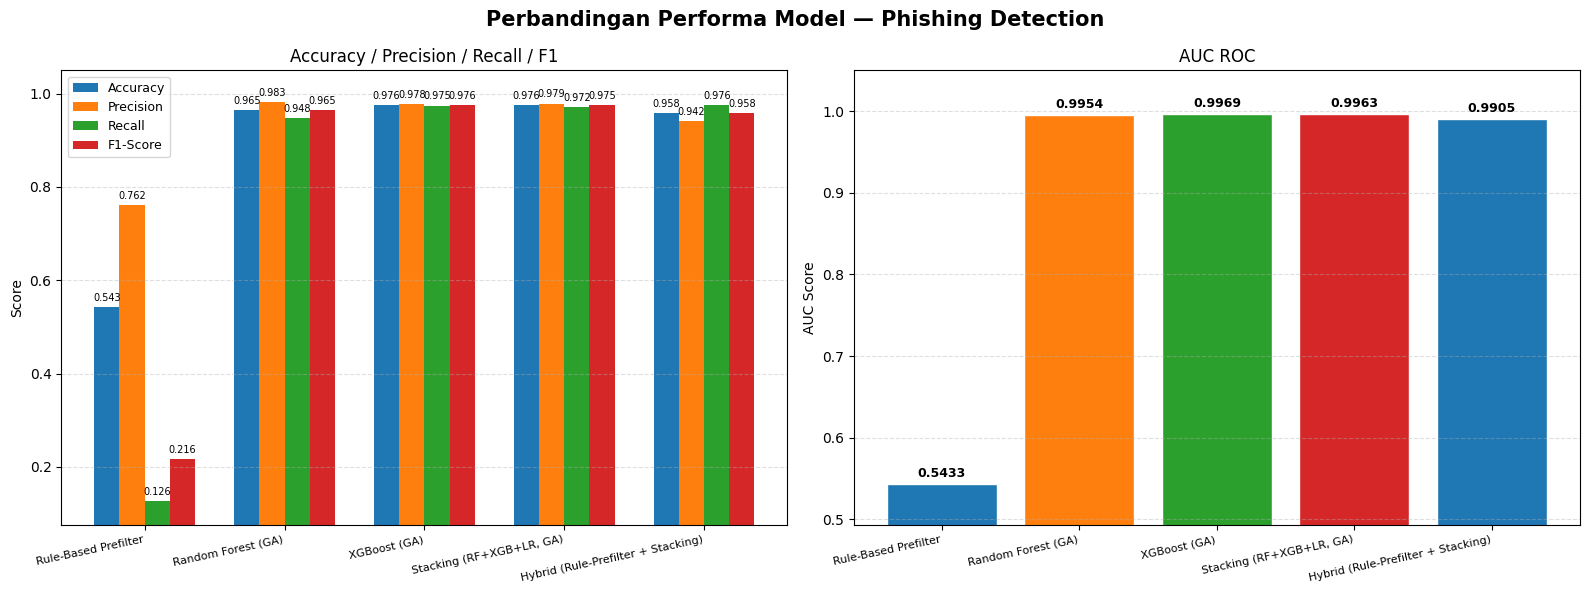

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Perbandingan Performa Model — Phishing Detection", fontsize=15, fontweight="bold")

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
model_names     = summary_df["Model"].tolist()
colors          = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
x = np.arange(len(model_names))
width = 0.18

# Grafik 1: Accuracy / Precision / Recall / F1
ax = axes[0]
for i, metric in enumerate(metrics_to_plot):
    vals = summary_df[metric].values
    bars = ax.bar(x + i*width, vals, width, label=metric, color=colors[i])
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x()+bar.get_width()/2, h),
                    xytext=(0,3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=7)
ax.set_ylabel("Score")
ax.set_title("Accuracy / Precision / Recall / F1")
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(model_names, rotation=12, ha="right", fontsize=8)
ax.legend(fontsize=9)
ax.set_ylim([max(0, summary_df[metrics_to_plot].values.min() - 0.05), 1.05])
ax.grid(axis="y", alpha=0.4, linestyle="--")

# Grafik 2: AUC
ax2 = axes[1]
auc_vals = summary_df["AUC"].fillna(0).values
bars = ax2.bar(model_names, auc_vals, color=colors, edgecolor="white")
for bar, v in zip(bars, auc_vals):
    ax2.annotate(f"{v:.4f}", xy=(bar.get_x()+bar.get_width()/2, v),
                 xytext=(0,3), textcoords="offset points",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_ylabel("AUC Score")
ax2.set_title("AUC ROC")
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels(model_names, rotation=12, ha="right", fontsize=8)
ax2.set_ylim([max(0, min(auc_vals)-0.05), 1.05])
ax2.grid(axis="y", alpha=0.4, linestyle="--")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Perbandingan Feature Mode 37 vs Hybrid 81

🔄 Training mode URL37...
[GA] Tuning Random Forest...
[GA] RF  best CV F1: 0.8736 | params: {'n_estimators': 337, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': None, 'random_state': 12, 'n_jobs': -1}
[GA] Tuning XGBoost...
[GA] XGB best CV F1: 0.88 | params: {'n_estimators': 184, 'learning_rate': 0.11192282774822035, 'max_depth': 10, 'subsample': 0.821855225913121, 'colsample_bytree': 0.7000654259253316, 'min_child_weight': 1.6686456405539047, 'gamma': 1.1384104669892272, 'reg_alpha': 0.09177155436054885, 'reg_lambda': 3.7994422815796987, 'eval_metric': 'logloss', 'random_state': 12, 'n_jobs': -1}
✓ url37 selesai

🔄 Training mode Hybrid81 (model sudah ada, reuse)...
✓ hybrid81 selesai

📊 URL Features (37)


,Model,Accuracy,Precision,Recall,F1-Score,AUC,TP,TN,FP,FN
0,Random Forest,0.8920,0.9125,0.8670,0.8892,0.9579,991,1048,95,152
1,XGBoost,0.8963,0.9187,0.8696,0.8935,0.9647,994,1055,88,149
2,Stacking,0.9033,0.9131,0.8915,0.9022,0.9644,1019,1046,97,124
3,Hybrid (Rule+Stacking),0.8924,0.8830,0.9046,0.8937,0.9467,1034,1006,137,109



📊 Hybrid Features (81)


,Model,Accuracy,Precision,Recall,F1-Score,AUC,TP,TN,FP,FN
0,Random Forest,0.9654,0.9828,0.9475,0.9648,0.9954,1083,1124,19,60
1,XGBoost,0.9764,0.9781,0.9746,0.9763,0.9969,1114,1118,25,29
2,Stacking,0.9755,0.9789,0.9720,0.9754,0.9963,1111,1119,24,32
3,Hybrid (Rule+Stacking),0.9576,0.9417,0.9755,0.9583,0.9905,1115,1074,69,28



📊 Perbandingan Δ (81 - 37)


,Model,Acc_37,Acc_81,Acc_Δ (%),F1_37,F1_81,F1_Δ (%),AUC_37,AUC_81
0,Random Forest,0.8920,0.9654,+7.35%,0.8892,0.9648,+7.56%,0.9579,0.9954
1,XGBoost,0.8963,0.9764,+8.01%,0.8935,0.9763,+8.29%,0.9647,0.9969
2,Stacking,0.9033,0.9755,+7.22%,0.9022,0.9754,+7.32%,0.9644,0.9963
3,Hybrid (Rule+Stacking),0.8924,0.9576,+6.52%,0.8937,0.9583,+6.46%,0.9467,0.9905


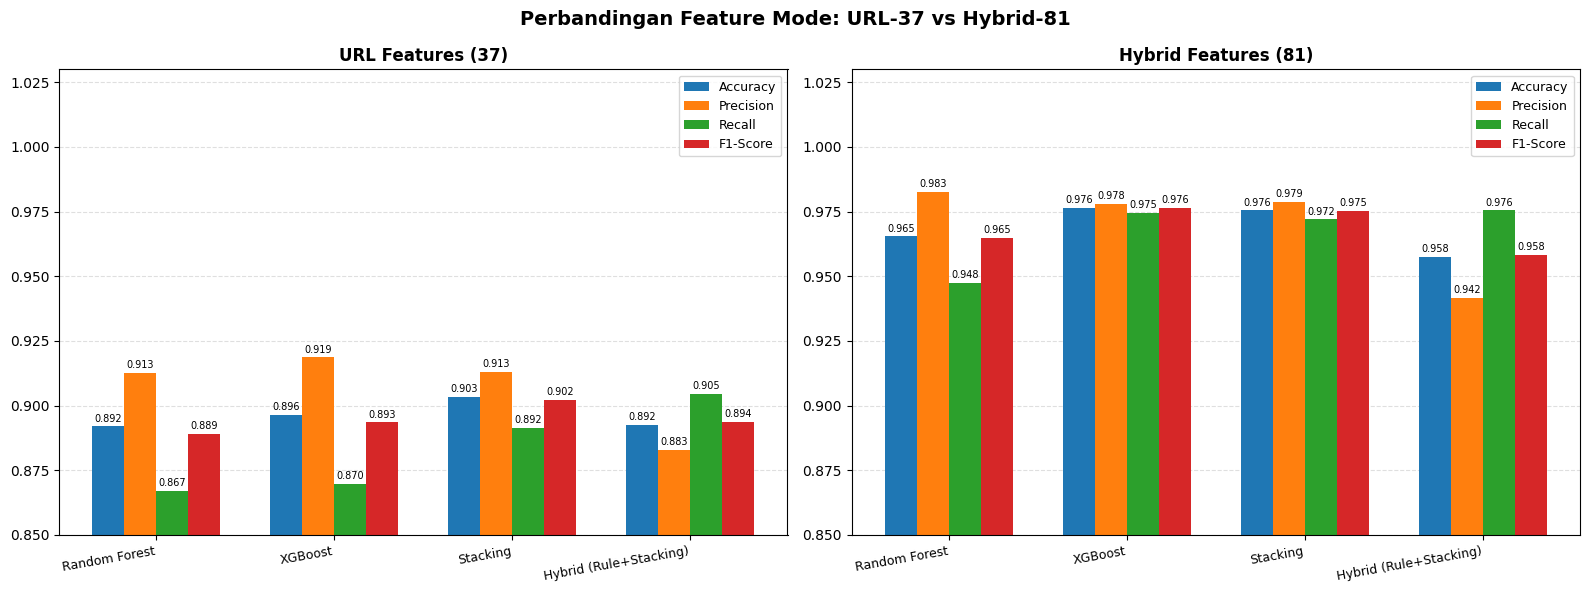

In [23]:
def build_pipeline_for_mode(feature_mode):
    """Melatih RF+XGB+Stacking GA-tuned untuk satu feature mode, persis train_model.py."""
    # Data preparation
    candidates = hybrid_features_81 if feature_mode == "hybrid81" else url_features_37
    X_tr = prep_X(df_clean, candidates, train_idx)
    X_te = prep_X(df_clean, candidates, test_idx)
    mask_ = X_tr.notna().any(axis=0)
    sel_f = X_tr.columns[mask_.to_numpy().astype(bool)].tolist()
    X_tr  = X_tr[sel_f].dropna()
    X_te  = X_te[sel_f].dropna()
    y_tr  = y_all.loc[X_tr.index]
    y_te  = y_all.loc[X_te.index]

    # GA tuning
    rf_p, _  = tune_rf_ga(X_tr, y_tr)
    xgb_p, _ = tune_xgb_ga(X_tr, y_tr)

    # Fit models
    rf_  = RandomForestClassifier(**rf_p).fit(X_tr, y_tr)
    xgb_ = XGBClassifier(**xgb_p).fit(X_tr, y_tr)
    stk_ = StackingClassifier(
        estimators=[("rf",rf_),("xgb",xgb_)],
        final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
        stack_method="predict_proba", n_jobs=-1,
    ).fit(X_tr, y_tr)

    # Evaluate
    rows = []
    for nm, mdl in [("Random Forest",rf_),("XGBoost",xgb_),("Stacking",stk_)]:
        p = mdl.predict_proba(X_te)[:,1]
        rows.append(compute_metrics(nm, y_te, (p>=FINAL_THRESHOLD).astype(int), p))

    # Rule-based eval for hybrid
    if "url" in df_clean.columns:
        url_s = df_clean.loc[X_te.index,"url"].fillna("")
        rule_r = [rule_based_eval(u) for u in url_s]
    else:
        feats_l = [dict(zip(X_te.columns,r)) for r in X_te.values]
        rule_r  = [rule_based_eval(f) for f in feats_l]
    rule_arr_ = np.array([r[2] for r in rule_r])
    rule_s_   = pd.Series(rule_arr_, index=X_te.index)
    hyb_p_, hyb_prb_ = hybrid_predict(X_te, rule_s_, stk_)
    rows.append(compute_metrics("Hybrid (Rule+Stacking)", y_te, hyb_p_, hyb_prb_))

    return pd.DataFrame([{k:v for k,v in r.items() if k!="cm"} for r in rows])


print("🔄 Training mode URL37...")
results_37_df = build_pipeline_for_mode("url37")
print("✓ url37 selesai")

print("\n🔄 Training mode Hybrid81 (model sudah ada, reuse)...")
# Reuse model yang sudah ditraining di cell sebelumnya untuk hybrid81
rows_81 = []
for nm, mdl in [("Random Forest",rf_ga),("XGBoost",xgb_ga),("Stacking",stack_ga)]:
    p = mdl.predict_proba(X_test)[:,1]
    rows_81.append(compute_metrics(nm, y_test, (p>=FINAL_THRESHOLD).astype(int), p))
hyb_p81, hyb_prb81 = hybrid_predict(X_test, y_pred_rule_series, stack_ga)
rows_81.append(compute_metrics("Hybrid (Rule+Stacking)", y_test, hyb_p81, hyb_prb81))
results_81_df = pd.DataFrame([{k:v for k,v in r.items() if k!="cm"} for r in rows_81])
print("✓ hybrid81 selesai")

# Tabel perbandingan
model_names_cmp = results_37_df["Model"].tolist()
comparison_df = pd.DataFrame({
    "Model":         model_names_cmp,
    "Acc_37":        results_37_df["Accuracy"].values,
    "Acc_81":        results_81_df["Accuracy"].values,
    "Acc_Δ (%)":     (results_81_df["Accuracy"].values - results_37_df["Accuracy"].values)*100,
    "F1_37":         results_37_df["F1-Score"].values,
    "F1_81":         results_81_df["F1-Score"].values,
    "F1_Δ (%)":      (results_81_df["F1-Score"].values - results_37_df["F1-Score"].values)*100,
    "AUC_37":        results_37_df["AUC"].values,
    "AUC_81":        results_81_df["AUC"].values,
})

print("\n📊 URL Features (37)")
display(results_37_df.style.format({c:"{:.4f}" for c in ["Accuracy","Precision","Recall","F1-Score","AUC"]})
        .background_gradient(cmap="RdYlGn", subset=["Accuracy","Precision","Recall","F1-Score","AUC"]))

print("\n📊 Hybrid Features (81)")
display(results_81_df.style.format({c:"{:.4f}" for c in ["Accuracy","Precision","Recall","F1-Score","AUC"]})
        .background_gradient(cmap="RdYlGn", subset=["Accuracy","Precision","Recall","F1-Score","AUC"]))

print("\n📊 Perbandingan Δ (81 - 37)")
display(comparison_df.style
        .format({"Acc_37":"{:.4f}","Acc_81":"{:.4f}","Acc_Δ (%)":"{:+.2f}%",
                 "F1_37":"{:.4f}","F1_81":"{:.4f}","F1_Δ (%)":"{:+.2f}%",
                 "AUC_37":"{:.4f}","AUC_81":"{:.4f}"})
        .background_gradient(cmap="RdYlGn", subset=["Acc_Δ (%)","F1_Δ (%)"])
        .set_caption("Peningkatan performa Hybrid81 vs URL37"))

# Visualisasi grouped bar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Perbandingan Feature Mode: URL-37 vs Hybrid-81", fontsize=14, fontweight="bold")
metrics_ = ["Accuracy","Precision","Recall","F1-Score"]
colors_  = ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]
x_ = np.arange(len(model_names_cmp)); w_ = 0.18

for ax_, df_, title_ in zip(axes, [results_37_df, results_81_df], ["URL Features (37)","Hybrid Features (81)"]):
    for i, metric in enumerate(metrics_):
        vals = df_[metric].values
        bars = ax_.bar(x_+i*w_, vals, w_, label=metric, color=colors_[i])
        for bar in bars:
            h = bar.get_height()
            ax_.annotate(f"{h:.3f}", xy=(bar.get_x()+bar.get_width()/2,h),
                         xytext=(0,2), textcoords="offset points",
                         ha="center", va="bottom", fontsize=7)
    ax_.set_title(title_, fontsize=12, fontweight="bold")
    ax_.set_xticks(x_+1.5*w_)
    ax_.set_xticklabels(model_names_cmp, rotation=10, ha="right", fontsize=9)
    ax_.legend(fontsize=9); ax_.set_ylim([0.85,1.03])
    ax_.grid(axis="y", alpha=0.4, linestyle="--"); ax_.set_axisbelow(True)

plt.tight_layout()
plt.savefig("mode_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. SHAP Analysis


  Global SHAP — Random Forest (GA)


100%|===================| 999/1000 [01:58<00:00]        

Top 10 Global SHAP Features (Random Forest (GA)):


,feature,mean_abs_shap
0,google_index,0.088808
1,page_rank,0.074854
2,nb_hyperlinks,0.041843
3,web_traffic,0.039083
4,nb_www,0.035831
5,domain_age,0.022004
6,phish_hints,0.019506
7,safe_anchor,0.015676
8,longest_word_path,0.013038
9,ratio_digits_url,0.013019


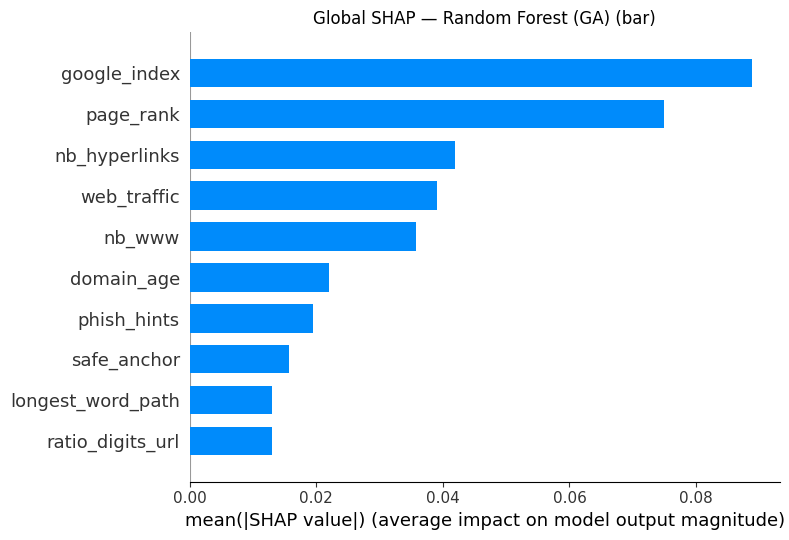

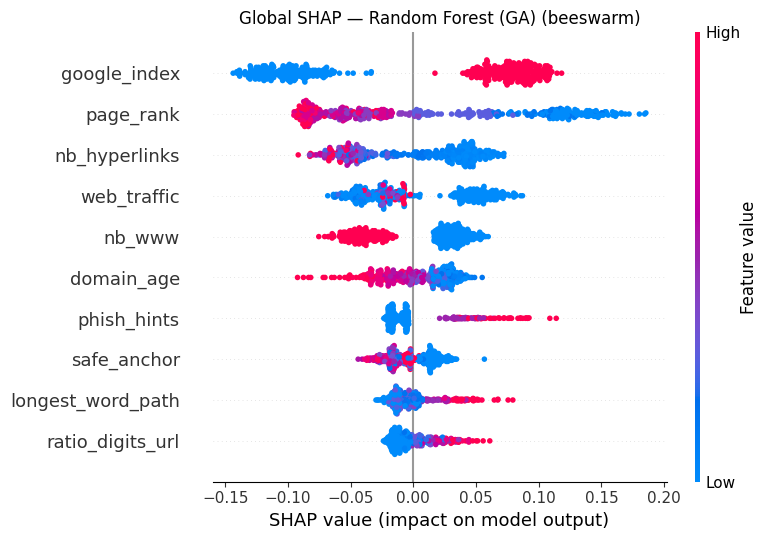


  Global SHAP — XGBoost (GA)
Top 10 Global SHAP Features (XGBoost (GA)):


,feature,mean_abs_shap
0,page_rank,1.529354
1,google_index,1.108413
2,nb_www,0.919833
3,nb_hyperlinks,0.724771
4,phish_hints,0.518834
5,domain_age,0.426741
6,nb_hyphens,0.378028
7,web_traffic,0.363105
8,nb_slash,0.350391
9,length_hostname,0.315243


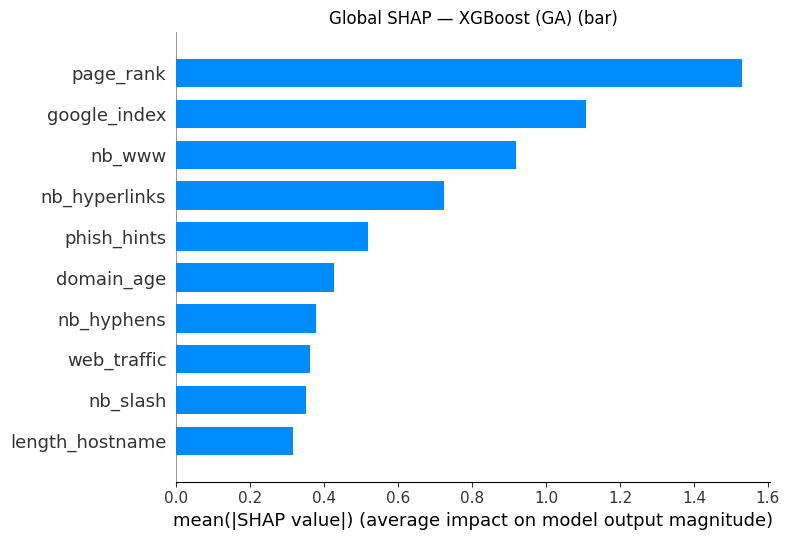

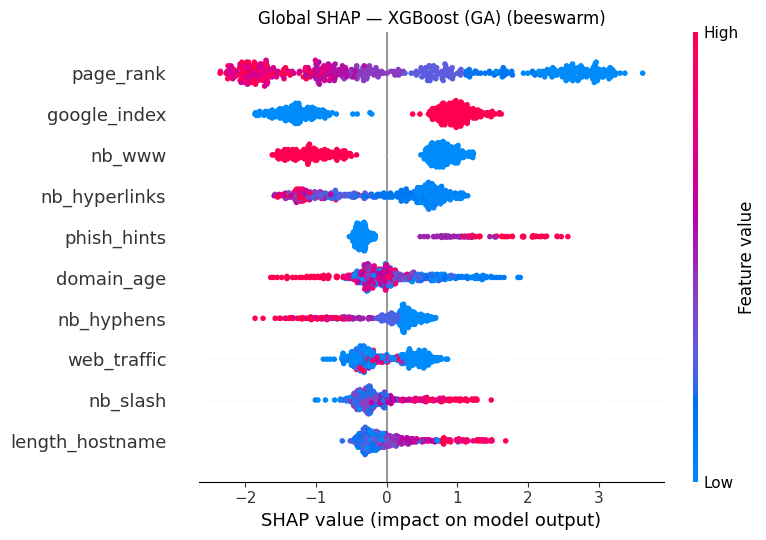


  Global SHAP — Stacking (GA)
Auto explainer gagal (The passed model is not callable and cannot be analyzed directly with the given masker! Model: StackingClassifier(estimators=[('rf',
                                RandomForestClassifier(max_depth=14,
                                                       max_features='log2',
                                                       min_samples_split=4,
                                                       n_estimators=464,
                                                       n_jobs=-1,
                                                       random_state=12)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=

100%|██████████| 500/500 [02:11<00:00,  3.80it/s]

Top 10 Global SHAP Features (Stacking (GA)):


,feature,mean_abs_shap
0,page_rank,0.085831
1,google_index,0.069391
2,nb_hyperlinks,0.029847
3,nb_www,0.025782
4,web_traffic,0.017840
5,phish_hints,0.012805
6,domain_age,0.011730
7,safe_anchor,0.010099
8,longest_word_path,0.007435
9,ratio_digits_url,0.006989


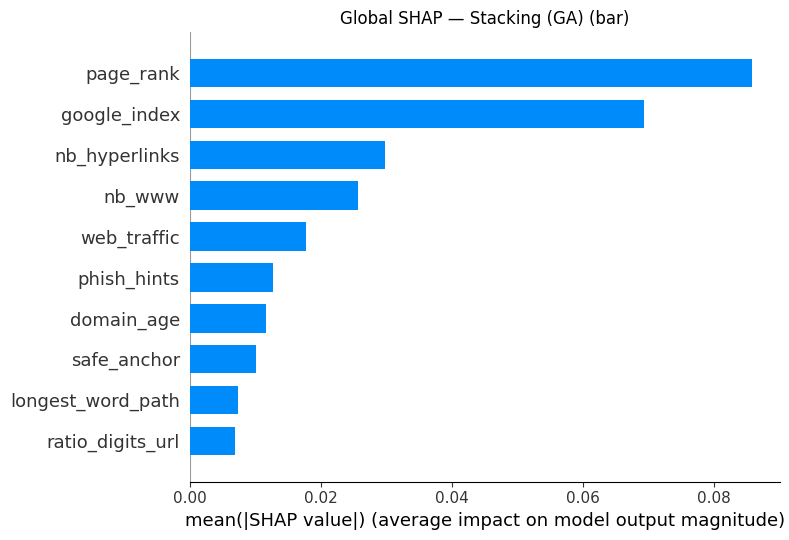

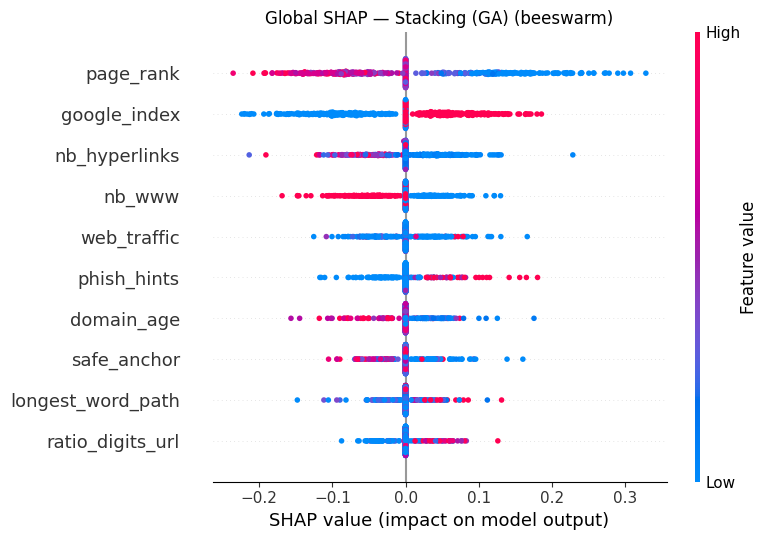

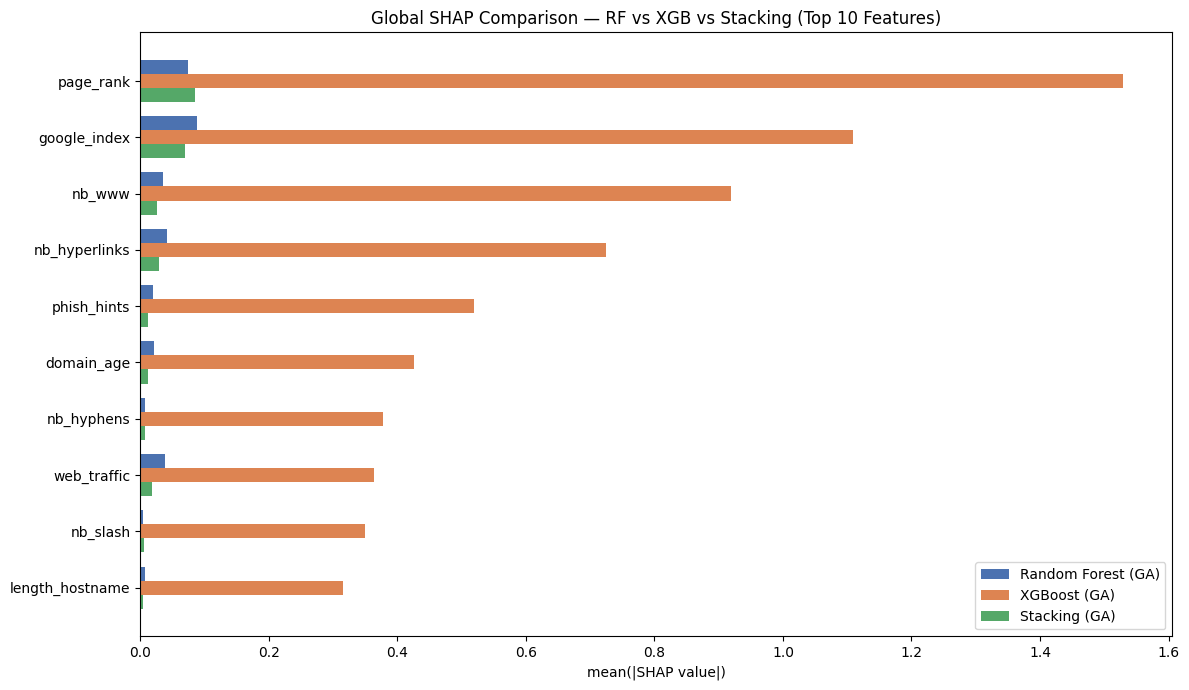

✅ Grafik perbandingan disimpan: shap_global_comparison.png

Empat URL yang akan dijelaskan SHAP:


,URL,STATUS,PHISHING_PROB
0,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,0.9500
1,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,0.9500
2,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,0.8775
3,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,0.9500


Auto explainer gagal (The passed model is not callable and cannot be analyzed directly with the given masker! Model: StackingClassifier(estimators=[('rf',
                                RandomForestClassifier(max_depth=14,
                                                       max_features='log2',
                                                       min_samples_split=4,
                                                       n_estimators=464,
                                                       n_jobs=-1,
                                                       random_state=12)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.7113303298877856,
           

100%|██████████| 4/4 [00:01<00:00,  3.40it/s]



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  URL 1: http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3717065149&id=100  [PHISHING]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ▶ Random Forest (GA) | p_phishing=0.798


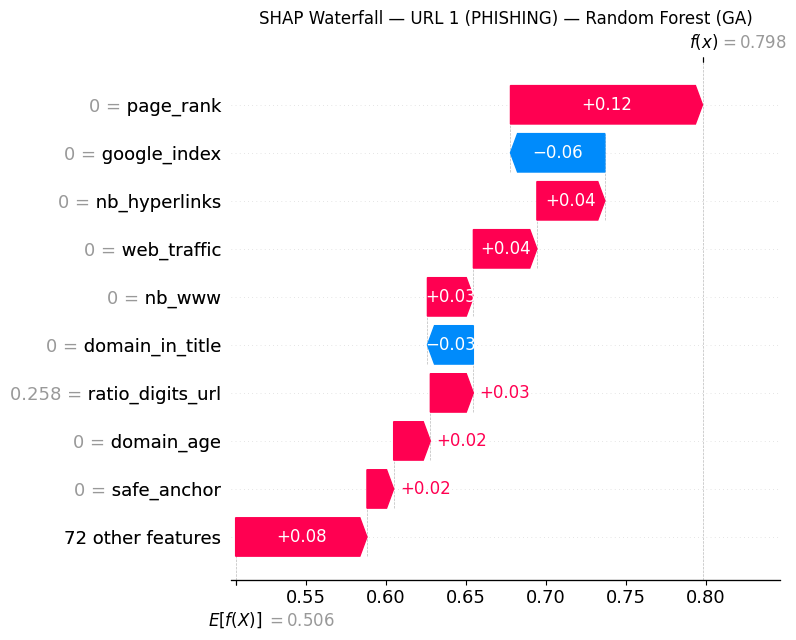


  ▶ XGBoost (GA) | p_phishing=0.976


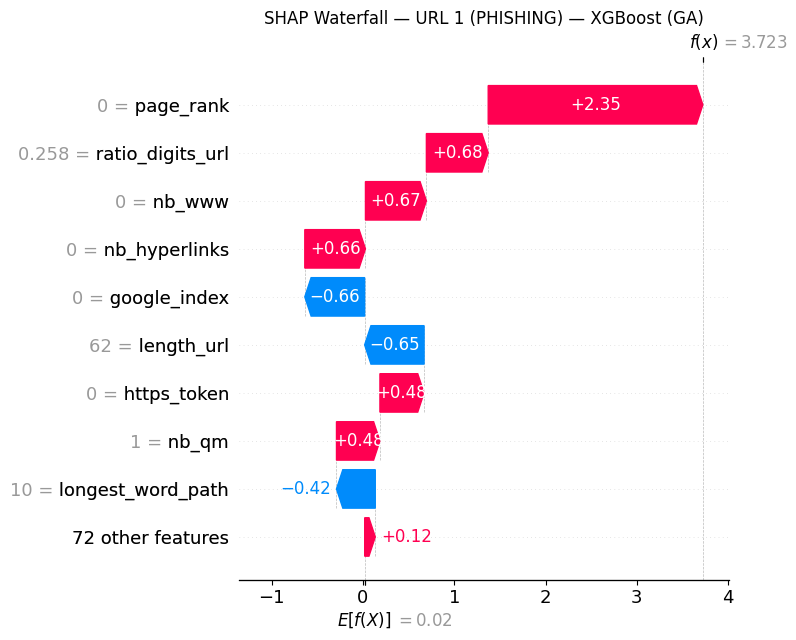


  ▶ Stacking (GA) | p_phishing=0.970


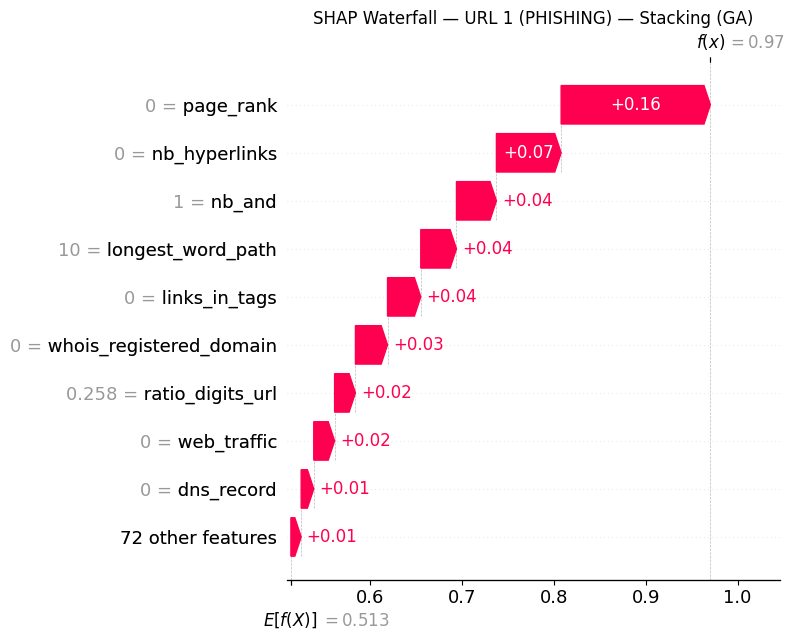


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  URL 2: http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3717065149&id=100  [PHISHING]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ▶ Random Forest (GA) | p_phishing=0.798


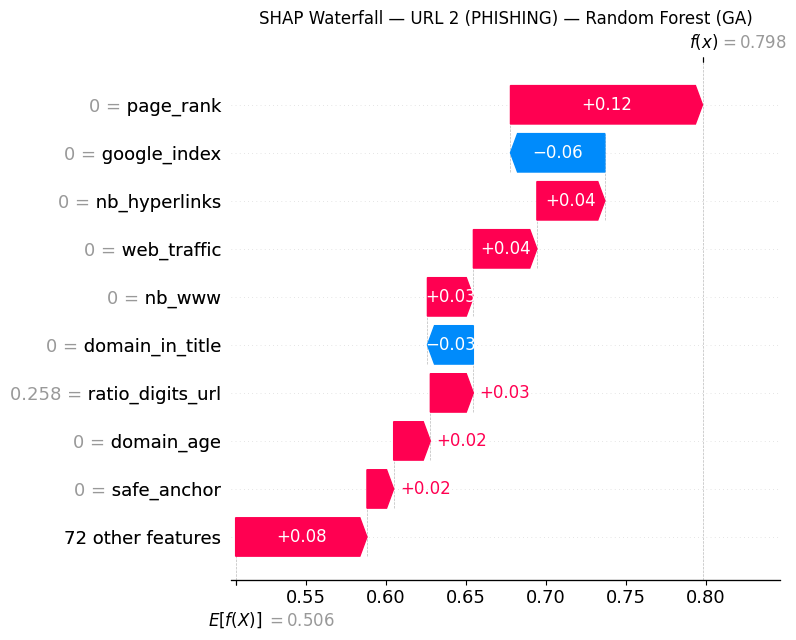


  ▶ XGBoost (GA) | p_phishing=0.976


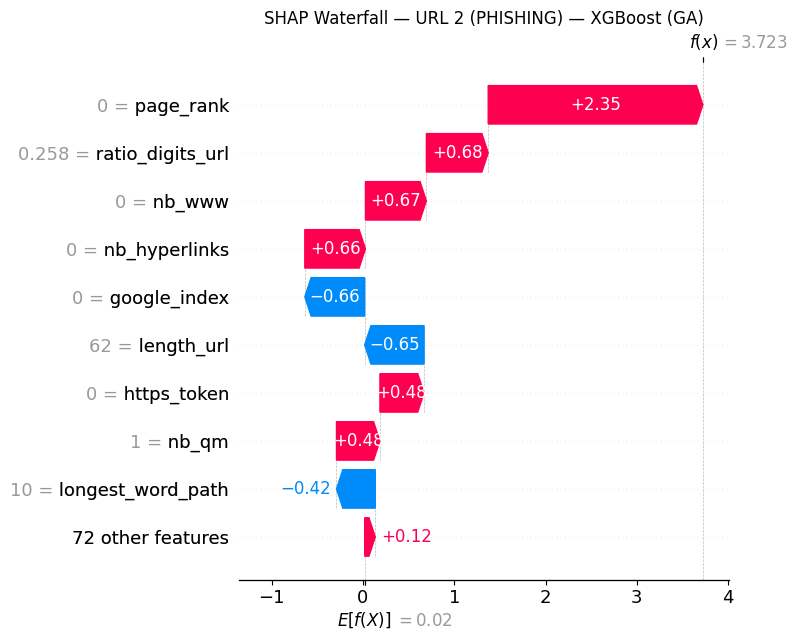


  ▶ Stacking (GA) | p_phishing=0.970


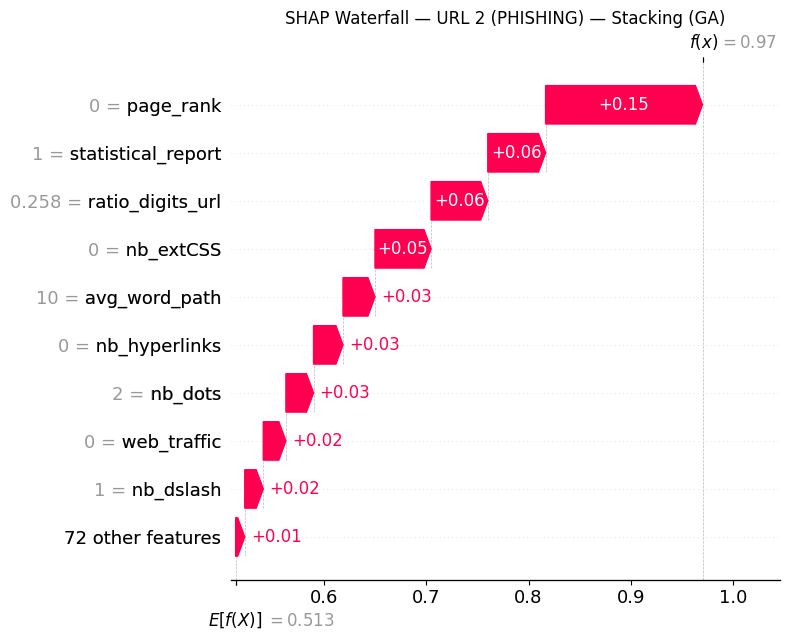


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  URL 3: http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3717065149&id=100  [PHISHING]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ▶ Random Forest (GA) | p_phishing=0.798


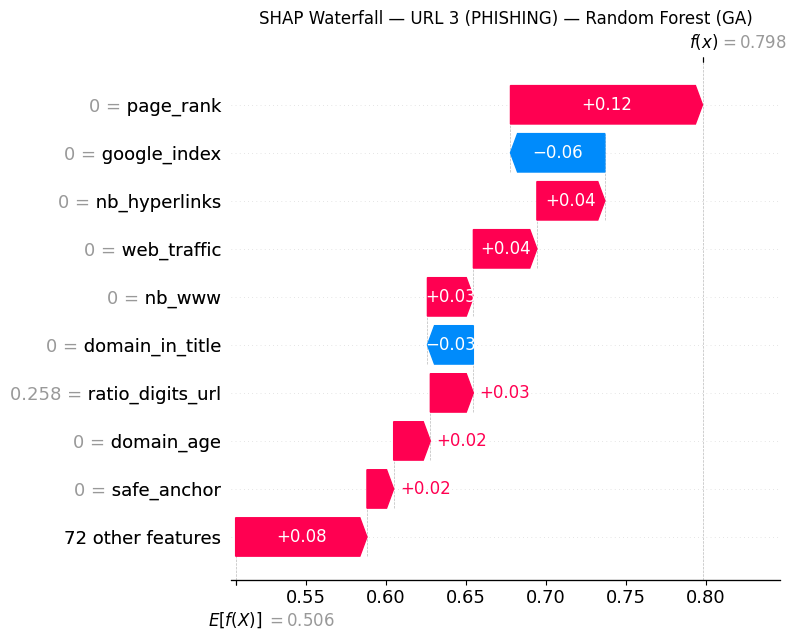


  ▶ XGBoost (GA) | p_phishing=0.976


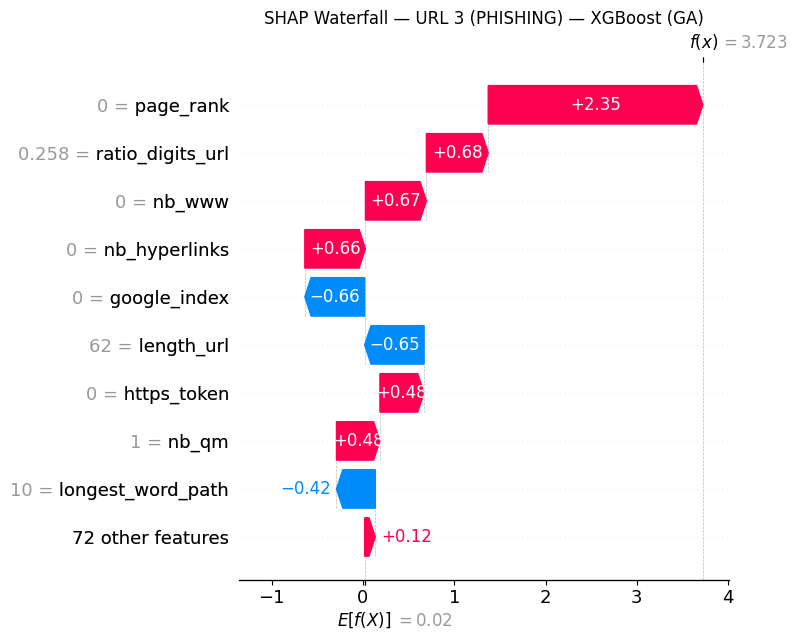


  ▶ Stacking (GA) | p_phishing=0.970


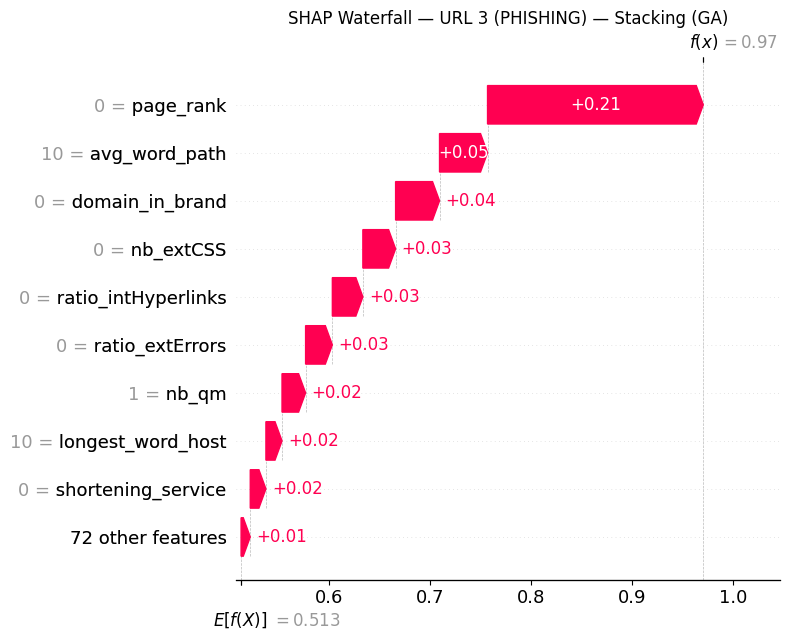


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  URL 4: http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3717065149&id=100  [PHISHING]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ▶ Random Forest (GA) | p_phishing=0.798


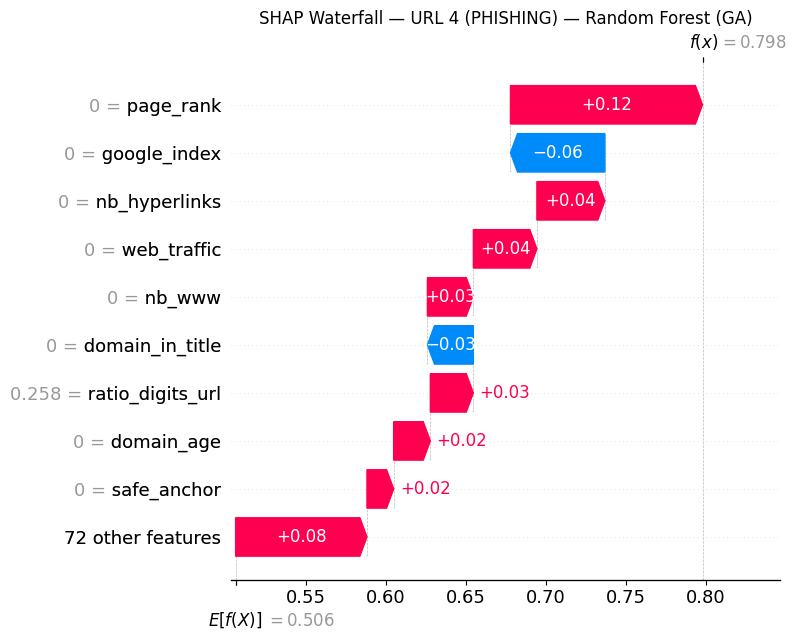


  ▶ XGBoost (GA) | p_phishing=0.976


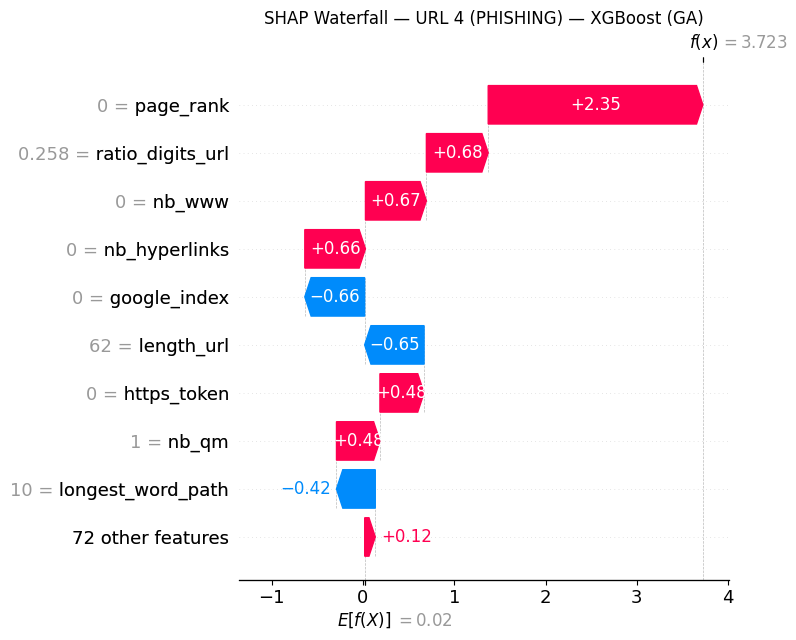


  ▶ Stacking (GA) | p_phishing=0.970


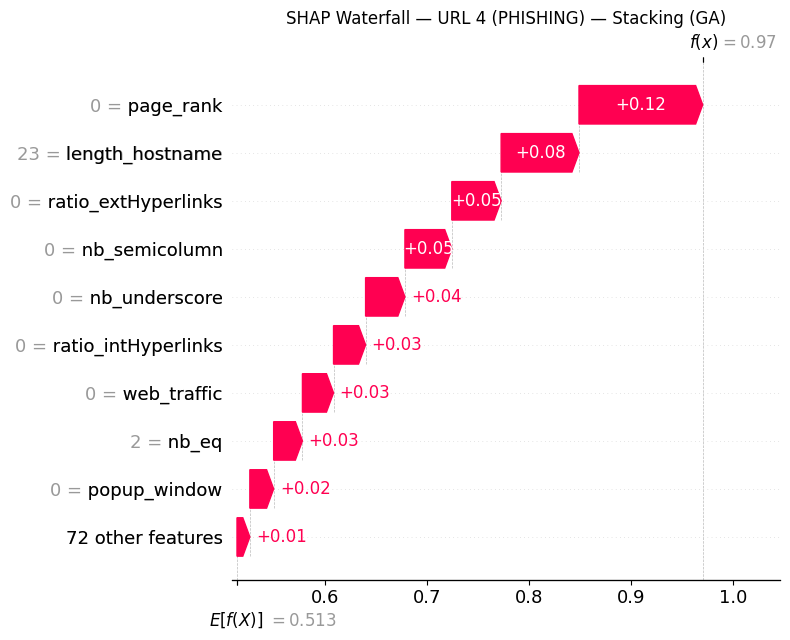


✅ SHAP lokal diekspor ke shap_local_export.csv (120 baris)


,url_no,url,status,model,p_phishing,rank,feature,feature_value,shap_signed,abs_shap,direction
0,1,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,Random Forest (GA),0.797932,1,page_rank,0.000000,0.120157,0.120157,PHISHING
1,1,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,Random Forest (GA),0.797932,2,google_index,0.000000,-0.059068,0.059068,BENIGN
2,1,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,Random Forest (GA),0.797932,3,nb_hyperlinks,0.000000,0.042533,0.042533,PHISHING
3,1,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,Random Forest (GA),0.797932,4,web_traffic,0.000000,0.039744,0.039744,PHISHING
4,1,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,Random Forest (GA),0.797932,5,nb_www,0.000000,0.028753,0.028753,PHISHING
5,1,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,Random Forest (GA),0.797932,6,domain_in_title,0.000000,-0.028731,0.028731,BENIGN
6,1,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,Random Forest (GA),0.797932,7,ratio_digits_url,0.258065,0.026904,0.026904,PHISHING
7,1,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,Random Forest (GA),0.797932,8,domain_age,0.000000,0.022952,0.022952,PHISHING
8,1,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,Random Forest (GA),0.797932,9,safe_anchor,0.000000,0.016706,0.016706,PHISHING
9,1,http://nmhokdypni.sum4iit.club/vnafvra97w/?q=3...,phishing,Random Forest (GA),0.797932,10,ratio_digits_host,0.043478,0.015261,0.015261,PHISHING


In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# 11. SHAP Analysis — Random Forest (GA), XGBoost (GA), dan Stacking (GA)
# ═══════════════════════════════════════════════════════════════════════════════

TOP_N          = 10
SHAP_BG_SIZE   = min(200, len(X_train))
SHAP_GLOBAL_SZ = min(500, len(X_test))

X_background  = shap.utils.sample(X_train, SHAP_BG_SIZE, random_state=RANDOM_STATE)
X_global_shap = shap.utils.sample(X_test,  SHAP_GLOBAL_SZ, random_state=RANDOM_STATE)

# ── Helper: seleksi nilai class-1 dari SHAP Explanation ───────────────────────
def _select_class1(explanation):
    values = np.asarray(explanation.values)
    base   = np.asarray(explanation.base_values)
    if values.ndim == 3:
        values = values[:, :, 1]
        if base.ndim == 2: base = base[:, 1]
    if base.ndim == 0:
        base = np.repeat(float(base), values.shape[0])
    return values, base

# ── Helper: normalisasi SHAP values ke bentuk 2D (n_samples, n_features) ──────
def _normalize_shap_vals(raw, n_features):
    """
    KernelExplainer bisa mengembalikan:
      - list of arrays (satu per kelas)   → ambil index 1 (class=phishing)
      - ndarray 3D (n_samples, n_feat, 2) → ambil [:, :, 1]
      - ndarray 2D (n_samples, n_feat)    → langsung pakai
    Pastikan output selalu 2D float dengan shape (n_samples, n_features).
    """
    if isinstance(raw, list):
        # list[n_classes] of (n_samples, n_features) → ambil class 1
        arr = np.asarray(raw[1] if len(raw) > 1 else raw[0])
    else:
        arr = np.asarray(raw)

    if arr.ndim == 3:
        # (n_samples, n_features, n_classes) → ambil class 1
        arr = arr[:, :, 1]
    elif arr.ndim == 1:
        # edge case: single sample flattened
        arr = arr.reshape(1, -1)

    # Pastikan kolom == n_features (buang kolom ekstra jika ada)
    arr = arr[:, :n_features].astype(float)
    return arr


# ── Helper: hitung SHAP dengan fallback ke KernelExplainer ────────────────────
def compute_shap(model, X_explain, background):
    n_feat = X_explain.shape[1]
    try:
        exp  = shap.Explainer(model, background)
        expl = exp(X_explain)
        vals, base = _select_class1(expl)
        # Pastikan vals 2D dan sesuai n_feat
        vals = _normalize_shap_vals(vals, n_feat)
        return exp, vals, base
    except Exception as e:
        print(f"Auto explainer gagal ({e}), fallback KernelExplainer")
        bg_small = shap.sample(background, min(50, len(background)))
        exp = shap.KernelExplainer(model.predict_proba, bg_small)
        raw = exp.shap_values(X_explain, nsamples=100)
        vals = _normalize_shap_vals(raw, n_feat)
        bv   = exp.expected_value
        bv_arr = np.asarray(bv).flatten()
        bv   = float(bv_arr[1] if len(bv_arr) > 1 else bv_arr[0])
        return exp, vals, np.repeat(bv, vals.shape[0])

# ── Helper: buat global SHAP DataFrame + plot bar + beeswarm ──────────────────
def run_global_shap(model, model_name, X_explain, background, top_n=TOP_N, prefix="shap_global"):
    print(f"\n{'='*60}")
    print(f"  Global SHAP — {model_name}")
    print(f"{'='*60}")
    _, shap_vals, _ = compute_shap(model, X_explain, background)

    mean_abs = np.abs(shap_vals).mean(axis=0)
    # Pastikan mean_abs 1D (bisa 2D jika shap_vals punya kolom ekstra)
    mean_abs = np.asarray(mean_abs).flatten()[:len(X_explain.columns)]
    df = (
        pd.DataFrame({"feature": list(X_explain.columns), "mean_abs_shap": mean_abs})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    print(f"Top {top_n} Global SHAP Features ({model_name}):")
    display(df.head(top_n))

    safe_name = model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_explain, plot_type="bar", max_display=top_n, show=False)
    plt.title(f"Global SHAP — {model_name} (bar)")
    plt.tight_layout()
    plt.savefig(f"{prefix}_{safe_name}_bar.png", dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_explain, max_display=top_n, show=False)
    plt.title(f"Global SHAP — {model_name} (beeswarm)")
    plt.tight_layout()
    plt.savefig(f"{prefix}_{safe_name}_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.show()

    return shap_vals, df


# ══════════════════════════════════════════════════════════════════════════════
# A) GLOBAL SHAP — 3 Model
# ══════════════════════════════════════════════════════════════════════════════

shap_vals_rf,  global_df_rf  = run_global_shap(rf_ga,    "Random Forest (GA)", X_global_shap, X_background)
shap_vals_xgb, global_df_xgb = run_global_shap(xgb_ga,   "XGBoost (GA)",       X_global_shap, X_background)
shap_vals_stk, global_df_stk = run_global_shap(stack_ga, "Stacking (GA)",       X_global_shap, X_background)

# ── Backward-compat: alias ke nama lama agar kode downstream tetap berjalan ──
shap_vals_global = shap_vals_xgb

# ── Perbandingan mean|SHAP| ketiga model dalam satu bar chart ─────────────────
fig, ax = plt.subplots(figsize=(12, 7))
top_features = global_df_xgb["feature"].head(TOP_N).tolist()

x = np.arange(len(top_features))
w = 0.25

for model_name, df_, color, offset in [
    ("Random Forest (GA)", global_df_rf,  "#4C72B0", -w),
    ("XGBoost (GA)",       global_df_xgb, "#DD8452",  0),
    ("Stacking (GA)",      global_df_stk, "#55A868",  w),
]:
    vals = [df_.set_index("feature")["mean_abs_shap"].get(f, 0) for f in top_features]
    ax.barh(x + offset, vals, w, label=model_name, color=color)

ax.set_yticks(x)
ax.set_yticklabels(top_features)
ax.invert_yaxis()
ax.set_xlabel("mean(|SHAP value|)")
ax.set_title(f"Global SHAP Comparison — RF vs XGB vs Stacking (Top {TOP_N} Features)")
ax.legend()
plt.tight_layout()
plt.savefig("shap_global_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik perbandingan disimpan: shap_global_comparison.png")


# ══════════════════════════════════════════════════════════════════════════════
# B) LOCAL SHAP dari log_feature_extraction.csv — 3 Model
# ══════════════════════════════════════════════════════════════════════════════

log_csv_path = pathlib.Path("log_feature_extraction.csv")
if log_csv_path.exists():
    log_df = pd.read_csv(
        log_csv_path,
        sep=";",
        on_bad_lines="warn",
        encoding="utf-8-sig",
        low_memory=False,
    )
    log_df.columns = log_df.columns.str.strip()

    missing_cols = [c for c in ["URL", "STATUS"] if c not in log_df.columns]
    if missing_cols:
        raise ValueError(f"Kolom wajib tidak ditemukan: {missing_cols}\n"
                         f"Kolom tersedia: {log_df.columns.tolist()}")

    local_log = log_df.tail(4).copy().reset_index(drop=True)
    print(f"\nEmpat URL yang akan dijelaskan SHAP:")
    display(local_log[["URL", "STATUS", "PHISHING_PROB"]
                       if "PHISHING_PROB" in local_log.columns else ["URL", "STATUS"]])

    feature_cols = list(X_train.columns)
    missing_feat  = [c for c in feature_cols if c not in local_log.columns]
    if missing_feat:
        print(f"⚠️  {len(missing_feat)} fitur tidak ada di log, diisi 0: {missing_feat[:5]}...")

    X_local = (
        local_log
        .reindex(columns=feature_cols, fill_value=0)
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
    )

    # Hitung SHAP lokal untuk ketiga model sekaligus
    _, shap_local_rf,  base_rf  = compute_shap(rf_ga,    X_local, X_background)
    _, shap_local_xgb, base_xgb = compute_shap(xgb_ga,   X_local, X_background)
    _, shap_local_stk, base_stk = compute_shap(stack_ga, X_local, X_background)

    proba_rf  = rf_ga.predict_proba(X_local)[:, 1]
    proba_xgb = xgb_ga.predict_proba(X_local)[:, 1]
    proba_stk = stack_ga.predict_proba(X_local)[:, 1]

    MODEL_LOCAL_CONFIGS = [
        ("Random Forest (GA)", shap_local_rf,  base_rf,  proba_rf,  "rf_ga"),
        ("XGBoost (GA)",       shap_local_xgb, base_xgb, proba_xgb, "xgb_ga"),
        ("Stacking (GA)",      shap_local_stk, base_stk, proba_stk, "stacking_ga"),
    ]

    for i in range(len(X_local)):
        label_ = str(local_log.loc[i, "STATUS"]).upper()
        url_   = local_log.loc[i, "URL"]
        print(f"\n{'━'*70}")
        print(f"  URL {i+1}: {url_}  [{label_}]")
        print(f"{'━'*70}")

        for model_name, shap_vals_loc, base_vals_loc, proba_arr, safe_key in MODEL_LOCAL_CONFIGS:
            p_ = proba_arr[i]
            print(f"\n  ▶ {model_name} | p_phishing={p_:.3f}")

            exp_i = shap.Explanation(
                values=shap_vals_loc[i],
                base_values=base_vals_loc[i],
                data=X_local.iloc[i].values,
                feature_names=feature_cols,
            )
            shap.plots.waterfall(exp_i, max_display=TOP_N, show=False)
            plt.title(f"SHAP Waterfall — URL {i+1} ({label_}) — {model_name}")
            plt.tight_layout()
            fname = f"shap_waterfall_url{i+1}_{safe_key}.png"
            plt.savefig(fname, dpi=150, bbox_inches="tight")
            plt.show()

    # ── Export ringkasan SHAP lokal ke CSV (semua model) ──────────────────────
    local_rows = []
    for i in range(len(X_local)):
        for model_name, shap_vals_loc, _, proba_arr, _ in MODEL_LOCAL_CONFIGS:
            signed  = shap_vals_loc[i]
            top_idx = np.argsort(np.abs(signed))[::-1][:TOP_N]
            for rank, j in enumerate(top_idx, 1):
                local_rows.append({
                    "url_no":        i + 1,
                    "url":           local_log.loc[i, "URL"],
                    "status":        local_log.loc[i, "STATUS"],
                    "model":         model_name,
                    "p_phishing":    float(proba_arr[i]),
                    "rank":          rank,
                    "feature":       feature_cols[j],
                    "feature_value": float(X_local.iloc[i, j]),
                    "shap_signed":   float(signed[j]),
                    "abs_shap":      float(abs(signed[j])),
                    "direction":     "PHISHING" if signed[j] > 0 else "BENIGN",
                })

    local_shap_df = pd.DataFrame(local_rows)
    local_shap_df.to_csv("shap_local_export.csv", index=False)
    print(f"\n✅ SHAP lokal diekspor ke shap_local_export.csv ({len(local_shap_df)} baris)")
    display(local_shap_df.head(30))

else:
    print("⚠️  log_feature_extraction.csv tidak ditemukan — lewati local SHAP.")
    print("   Letakkan file log (separator=;) di folder yang sama dengan notebook.")


## 12. Simpan Model & Laporan GA

In [26]:
import pickle, json

suffix = "_81" if ACTIVE_TRAIN_FEATURES == "hybrid81" else "_37"

with open(f"random_forest_model{suffix}.pkl","wb") as f: pickle.dump(rf_ga, f)
with open(f"xgboost_model{suffix}.pkl","wb") as f: pickle.dump(xgb_ga, f)
with open(f"rule_lr{suffix}.pkl","wb") as f: pickle.dump(stack_ga.final_estimator_, f)
with open(f"feature_columns{suffix}.txt","w",encoding="utf-8") as f:
    f.write("\n".join(selected_features))

ga_report = {
    "random_state": RANDOM_STATE, "feature_mode": ACTIVE_TRAIN_FEATURES,
    "ga": {
        "population": GA_POP_SIZE, "generations": GA_N_GEN, "cv_splits": GA_CV_SPLITS,
        "rf_best_cv_f1": best_rf_cv_f1, "xgb_best_cv_f1": best_xgb_cv_f1,
        "rf_best_params": best_rf_params, "xgb_best_params": best_xgb_params,
    }
}
with open(f"ga_tuning_report{suffix}.json","w",encoding="utf-8") as f:
    json.dump(ga_report, f, indent=2)

print(f"✅ Model & metadata (suffix={suffix}) tersimpan.")
print(f"   random_forest_model{suffix}.pkl")
print(f"   xgboost_model{suffix}.pkl")
print(f"   rule_lr{suffix}.pkl  (stacking final_estimator_)")
print(f"   feature_columns{suffix}.txt  ({len(selected_features)} fitur)")
print(f"   ga_tuning_report{suffix}.json")

✅ Model & metadata (suffix=_81) tersimpan.
   random_forest_model_81.pkl
   xgboost_model_81.pkl
   rule_lr_81.pkl  (stacking final_estimator_)
   feature_columns_81.txt  (81 fitur)
   ga_tuning_report_81.json
